# VIX–VXN Relative Spread: Regimes, Compression Dynamics, and Market Behavior

This notebook investigates whether the relative spread between VXN and VIX carries useful information about market behavior.

The focus is not on predicting direction, but on understanding whether the spread helps characterize when taking risk is more or less favorable.

The analysis is intentionally kept simple:

- one core variable: relative spread  
- one event definition: rolling 252-day p10 threshold  
- one dependence control: 21-day cooldown  
- two main dimensions: compression dynamics and local positioning  

The goal is not to build a trading signal, but to evaluate whether the spread can be used as a **risk regime filter**.

In [1]:
!pip install yfinance -q

import pandas as pd
import numpy as np
import yfinance as yf

## 1. Data download and preprocessing

We use three daily time series from Yahoo Finance:

- S&P 500 (`^GSPC`)
- VIX (`^VIX`)
- VXN (`^VXN`)

The objective of this section is to build a clean, aligned daily dataset using closing prices only.

In [2]:
tickers = {
    "SPX": "^GSPC",
    "VIX": "^VIX",
    "VXN": "^VXN",
}

start_date = "2006-01-01"
end_date = None


def download_close_series(ticker: str, col_name: str) -> pd.DataFrame:
    """
    Download daily price data from Yahoo Finance and return a clean Close series.

    - Uses adjusted prices
    - Handles MultiIndex columns if present
    - Returns a time-indexed DataFrame with a single column
    """
    df = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        progress=False,
        auto_adjust=True
    )

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df[["Close"]].copy()
    df = df.rename(columns={"Close": col_name})

    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    return df


# download series
spx = download_close_series(tickers["SPX"], "SPX")
vix = download_close_series(tickers["VIX"], "VIX")
vxn = download_close_series(tickers["VXN"], "VXN")

# align datasets on common dates
df = spx.join(vix, how="inner").join(vxn, how="inner")
df.columns.name = None

# quick sanity checks
print("Shape:", df.shape)
print("\nNaNs by column:")
print(df.isna().sum())
print("\nDuplicated dates:", df.index.duplicated().sum())
print("Index sorted:", df.index.is_monotonic_increasing)

df.head()

Shape: (5096, 3)

NaNs by column:
SPX    0
VIX    0
VXN    0
dtype: int64

Duplicated dates: 0
Index sorted: True


,SPX,VIX,VXN
Date,,,
2006-01-03,1268.800049,11.14,14.69
2006-01-04,1273.459961,11.37,14.85
2006-01-05,1273.479980,11.31,15.01
2006-01-06,1285.449951,11.00,14.95
2006-01-09,1290.150024,11.13,15.66


## 2. Core variable and event definition

The core variable is the relative spread:

`spread_rel = (VXN - VIX) / VIX`

This normalization is important because absolute spreads are not directly comparable across different volatility regimes.

An event is defined when the relative spread falls below its rolling 252-day 10th percentile.

To avoid look-ahead bias, the threshold is shifted so that each event is evaluated using only information available at that point in time.

A 21-day cooldown is then applied to reduce event clustering.

In [3]:
# core variables
df["spread"] = df["VXN"] - df["VIX"]
df["spread_rel"] = (df["VXN"] - df["VIX"]) / df["VIX"]

# rolling 252-day 10th percentile, shifted to avoid look-ahead bias
df["th_252d"] = (
    df["spread_rel"]
    .rolling(window=252, min_periods=252)
    .quantile(0.10)
    .shift(1)
)

# raw event: relative spread below rolling p10 threshold
df["event_raw_252d"] = df["spread_rel"] <= df["th_252d"]


def make_event_with_cooldown(signal: pd.Series, cooldown: int = 21) -> pd.Series:
    """
    Convert a raw boolean signal into event dates with a cooldown window.

    Once an event is triggered, new events are suppressed for the next
    `cooldown` trading days to reduce clustering.
    """
    event = pd.Series(False, index=signal.index)
    last_event_pos = -10_000  # far in the past

    for i in range(len(signal)):
        if pd.notna(signal.iloc[i]) and signal.iloc[i]:
            if i - last_event_pos > cooldown:
                event.iloc[i] = True
                last_event_pos = i

    return event


df["event_252d"] = make_event_with_cooldown(df["event_raw_252d"], cooldown=21)

print("Number of events:", int(df["event_252d"].sum()))

df.loc[df["event_252d"], ["VIX", "VXN", "spread_rel", "th_252d"]].head(10)

Number of events: 81


,VIX,VXN,spread_rel,th_252d
Date,,,,
2007-02-27,18.309999,22.969999,0.254506,0.279342
2007-03-29,15.140000,18.530001,0.223910,0.259794
2007-05-11,12.950000,16.090000,0.242471,0.254581
2007-06-13,14.730000,15.810000,0.073320,0.241837
2007-07-16,15.590000,16.549999,0.061578,0.153944
2007-08-15,30.670000,27.969999,-0.088034,0.084523
2008-09-15,31.700001,32.130001,0.013565,0.093825
2008-10-15,69.250000,72.930000,0.053141,0.071966
2008-11-14,66.309998,66.050003,-0.003921,0.034783


## 3. Forward returns and baseline comparison

We compute forward returns for the S&P 500 at different horizons:

- 5 days
- 21 days
- 63 days

The goal is to compare:

- unconditional (baseline) returns  
- returns following extreme compression events  

This allows us to evaluate whether the spread carries **useful information about the distribution of future returns**, rather than acting as a direct directional signal.

In [4]:
# forward returns
df["r_5d"] = df["SPX"].shift(-5) / df["SPX"] - 1
df["r_21d"] = df["SPX"].shift(-21) / df["SPX"] - 1
df["r_63d"] = df["SPX"].shift(-63) / df["SPX"] - 1


def summarize_returns(df: pd.DataFrame, mask: pd.Series, label: str) -> pd.DataFrame:
    """
    Summarize forward returns for a selected subset of observations.

    Metrics reported:
    - mean
    - median
    - hit rate (share of positive returns)
    """
    subset = df.loc[mask]

    return pd.DataFrame({
        "group": [label],
        "n": [len(subset)],
        "mean_5d": [subset["r_5d"].mean()],
        "median_5d": [subset["r_5d"].median()],
        "hit_5d": [(subset["r_5d"] > 0).mean()],
        "mean_21d": [subset["r_21d"].mean()],
        "median_21d": [subset["r_21d"].median()],
        "hit_21d": [(subset["r_21d"] > 0).mean()],
        "mean_63d": [subset["r_63d"].mean()],
        "median_63d": [subset["r_63d"].median()],
        "hit_63d": [(subset["r_63d"] > 0).mean()],
    })


baseline = summarize_returns(df, df["r_21d"].notna(), "baseline")
events = summarize_returns(df, df["event_252d"], "event_252d")

results = pd.concat([baseline, events], ignore_index=True)

results

,group,n,mean_5d,median_5d,hit_5d,mean_21d,median_21d,hit_21d,mean_63d,median_63d,hit_63d
0,baseline,5075,0.001939,0.003719,0.591330,0.007941,0.014157,0.659901,0.024150,0.036194,0.704236
1,event_252d,81,0.003294,0.006399,0.604938,0.012053,0.019356,0.666667,0.034138,0.046992,0.716049


## 4. Regime conditioning (MA200)

We condition the signal on market regime using a simple filter:

- SPX above MA200 → bull regime  
- SPX below MA200 → bear regime  

This tests whether the behavior of the spread depends on broader market context, rather than being uniform across market conditions.

In [5]:
# MA200 regime definition
df["ma200"] = df["SPX"].rolling(200).mean()
df["spx_above_ma200"] = df["SPX"] > df["ma200"]

# conditional performance by regime
events_above = summarize_returns(
    df,
    df["event_252d"] & df["spx_above_ma200"],
    "event_above_ma200"
)

events_below = summarize_returns(
    df,
    df["event_252d"] & (~df["spx_above_ma200"]),
    "event_below_ma200"
)

# combine results
regime_results = pd.concat(
    [baseline, events, events_above, events_below],
    ignore_index=True
)

regime_results

,group,n,mean_5d,median_5d,hit_5d,mean_21d,median_21d,hit_21d,mean_63d,median_63d,hit_63d
0,baseline,5075,0.001939,0.003719,0.591330,0.007941,0.014157,0.659901,0.024150,0.036194,0.704236
1,event_252d,81,0.003294,0.006399,0.604938,0.012053,0.019356,0.666667,0.034138,0.046992,0.716049
2,event_above_ma200,54,0.003837,0.006106,0.592593,0.015436,0.019840,0.685185,0.036139,0.042061,0.777778
3,event_below_ma200,27,0.002208,0.010709,0.629630,0.005289,0.019294,0.629630,0.030211,0.051923,0.592593


## 5. Compression dynamics

We now evaluate whether the *magnitude and speed of compression* carry more information than the spread level itself.

Instead of focusing only on extreme spread values, we look at how the spread evolves leading into the event.

This helps distinguish between:

- **intensity** — how large the compression has been over a broader window  
- **speed** — how fast the compression has happened more recently

In [6]:
# compression intensity over 21 trading days
df["compress_delta_21d"] = df["spread_rel"] - df["spread_rel"].shift(21)

# compression speed over 3 trading days
df["compress_delta_3d"] = df["spread_rel"] - df["spread_rel"].shift(3)

# keep only event observations with forward returns and dynamics available
df_dyn = df.loc[df["event_252d"]].copy()
df_dyn = df_dyn.dropna(subset=["compress_delta_21d", "compress_delta_3d", "r_21d", "r_63d"]).copy()

# intensity buckets
int_bins = pd.qcut(df_dyn["compress_delta_21d"], q=3, duplicates="drop")
int_labels = ["strong", "medium", "weak"][:len(int_bins.cat.categories)]
df_dyn["intensity"] = int_bins.cat.rename_categories(int_labels)

# speed buckets
spd_bins = pd.qcut(df_dyn["compress_delta_3d"], q=2, duplicates="drop")
spd_labels = ["fast", "slow"][:len(spd_bins.cat.categories)]
df_dyn["speed"] = spd_bins.cat.rename_categories(spd_labels)


def summarize_dyn(mask: pd.Series, label: str) -> pd.DataFrame:
    """
    Summarize forward returns for a selected subset of event observations.
    """
    sub = df_dyn.loc[mask]
    return pd.DataFrame({
        "group": [label],
        "n": [len(sub)],
        "mean_21d": [sub["r_21d"].mean()],
        "hit_21d": [(sub["r_21d"] > 0).mean()],
        "mean_63d": [sub["r_63d"].mean()],
        "hit_63d": [(sub["r_63d"] > 0).mean()],
    })


dyn_results = pd.concat([
    summarize_dyn(df_dyn["intensity"] == "strong", "strong"),
    summarize_dyn(df_dyn["speed"] == "fast", "fast"),
    summarize_dyn((df_dyn["intensity"] == "strong") & (df_dyn["speed"] == "fast"), "strong_fast"),
], ignore_index=True)

dyn_results

,group,n,mean_21d,hit_21d,mean_63d,hit_63d
0,strong,27,0.028012,0.851852,0.034308,0.703704
1,fast,40,0.022035,0.775000,0.026358,0.700000
2,strong_fast,23,0.029901,0.913043,0.035495,0.695652


## 6. Robustness check: local floor positioning

As an alternative formulation, we test whether the spread carries information not only through recent compression dynamics, but also through its position relative to a recent local minimum.

We define:

- a 64-day local minimum of the relative spread  
- the current distance from that local minimum  
- a rolling 252-day percentile of that distance  

This helps distinguish two different effects:

- **compression dynamics** — how sharply the spread has moved into the event  
- **local floor positioning** — how close the spread still is to its recent minimum

In [7]:
# 6. Robustness check: compression dynamics vs local floor positioning

# comparison base: event observations with forward returns available
df_cmp = df.loc[df["event_252d"]].copy()
df_cmp = df_cmp.dropna(subset=["r_21d", "r_63d"]).copy()

# -----------------------------------
# A) Compression dynamics
# -----------------------------------
df_cmp["compress_delta_21d"] = df_cmp["spread_rel"] - df_cmp["spread_rel"].shift(21)
df_cmp["compress_delta_3d"] = df_cmp["spread_rel"] - df_cmp["spread_rel"].shift(3)

# intensity buckets
int_bins = pd.qcut(df_cmp["compress_delta_21d"], q=3, duplicates="drop")
int_labels = ["strong", "medium", "weak"][:len(int_bins.cat.categories)]
df_cmp["intensity"] = int_bins.cat.rename_categories(int_labels)

# speed buckets
spd_bins = pd.qcut(df_cmp["compress_delta_3d"], q=2, duplicates="drop")
spd_labels = ["fast", "slow"][:len(spd_bins.cat.categories)]
df_cmp["speed"] = spd_bins.cat.rename_categories(spd_labels)

# -----------------------------------
# B) Local floor positioning
# -----------------------------------
df_floor = df.copy()

# 64-day local minimum: today + previous 63 trading days
df_floor["spread_min_64"] = df_floor["spread_rel"].rolling(window=64, min_periods=64).min()

# current distance from local floor
df_floor["spread_pos_64"] = df_floor["spread_rel"] - df_floor["spread_min_64"]


def rolling_percentile_last(x):
    """
    Return the percentile rank of the last observation within the rolling window.
    """
    s = pd.Series(x)
    return s.rank(pct=True).iloc[-1]


# rolling 252-day percentile of local-floor distance
df_floor["spread_pos_64_pct"] = (
    df_floor["spread_pos_64"]
    .rolling(window=252, min_periods=252)
    .apply(rolling_percentile_last, raw=False)
    .shift(1)
)

# bring local-floor variables into comparison frame
df_cmp["spread_pos_64"] = df_floor.loc[df_cmp.index, "spread_pos_64"]
df_cmp["spread_pos_64_pct"] = df_floor.loc[df_cmp.index, "spread_pos_64_pct"]

# local-floor filters
df_cmp["near_floor_33"] = df_cmp["spread_pos_64_pct"] <= 0.33
df_cmp["near_floor_20"] = df_cmp["spread_pos_64_pct"] <= 0.20

# keep only observations with all required inputs
df_cmp = df_cmp.dropna(subset=[
    "compress_delta_21d",
    "compress_delta_3d",
    "spread_pos_64",
    "spread_pos_64_pct",
    "r_21d",
    "r_63d"
]).copy()


def summarize_group(data: pd.DataFrame, mask: pd.Series, label: str) -> pd.DataFrame:
    """
    Summarize forward returns for a selected comparison group.
    """
    sub = data.loc[mask]
    return pd.DataFrame({
        "group": [label],
        "n": [len(sub)],
        "mean_21d": [sub["r_21d"].mean()],
        "median_21d": [sub["r_21d"].median()],
        "hit_21d": [(sub["r_21d"] > 0).mean()],
        "mean_63d": [sub["r_63d"].mean()],
        "median_63d": [sub["r_63d"].median()],
        "hit_63d": [(sub["r_63d"] > 0).mean()],
    })


comparison_results = pd.concat([
    summarize_group(df_cmp, pd.Series(True, index=df_cmp.index), "base_event_252d"),
    summarize_group(df_cmp, (df_cmp["intensity"] == "strong") & (df_cmp["speed"] == "fast"), "A_strong_fast"),
    summarize_group(df_cmp, df_cmp["near_floor_33"], "B_near_floor_33"),
    summarize_group(df_cmp, df_cmp["near_floor_20"], "B_near_floor_20"),
], ignore_index=True)

comparison_results

,group,n,mean_21d,median_21d,hit_21d,mean_63d,median_63d,hit_63d
0,base_event_252d,59,0.020323,0.026750,0.728814,0.043678,0.055635,0.796610
1,A_strong_fast,13,0.038401,0.036479,0.846154,0.059076,0.042061,0.846154
2,B_near_floor_33,40,0.016909,0.019325,0.725000,0.043543,0.046992,0.850000
3,B_near_floor_20,34,0.014639,0.021548,0.794118,0.037061,0.041693,0.823529


## 7. Conclusion

The relative VXN–VIX spread does not behave as a reliable standalone directional signal.

Three main findings emerge:

1. **Spread level alone is weak**
2. **Market regime matters**, with stronger behavior above MA200
3. **Compression dynamics and local positioning capture different dimensions of the signal**

Compression dynamics tend to improve forward return magnitude, while local positioning appears to improve consistency.

Taken together, the spread is better interpreted as a **state-dependent risk filter**, rather than a directional predictor.

In isolation, the signal is not sufficient to form a standalone strategy.  
However, it becomes more meaningful when used to adjust exposure depending on market conditions.

## 8. Practical application: signal as a risk overlay

We now evaluate whether the signal can be used in a simple allocation framework.

Rather than using it as a standalone strategy, we test its role as a **risk overlay**:

- increase exposure when conditions are favorable  
- reduce exposure otherwise  

This allows us to assess whether the signal improves risk-adjusted performance.

In [8]:
# NOTE:
# This is a naive standalone implementation.
# It is expected to perform poorly, as the signal is not designed
# to be used in isolation.

df_test = df.copy()

df_test["compress_delta_21d"] = df_test["spread_rel"] - df_test["spread_rel"].shift(21)
df_test["compress_delta_3d"] = df_test["spread_rel"] - df_test["spread_rel"].shift(3)

df_tmp = df_test.loc[df_test["event_252d"]].copy()
df_tmp = df_tmp.dropna(subset=["compress_delta_21d", "compress_delta_3d"]).copy()

int_bins = pd.qcut(df_tmp["compress_delta_21d"], q=3, duplicates="drop")
int_labels = ["strong", "medium", "weak"][:len(int_bins.cat.categories)]
df_tmp["intensity"] = int_bins.cat.rename_categories(int_labels)

spd_bins = pd.qcut(df_tmp["compress_delta_3d"], q=2, duplicates="drop")
spd_labels = ["fast", "slow"][:len(spd_bins.cat.categories)]
df_tmp["speed"] = spd_bins.cat.rename_categories(spd_labels)

df_tmp["A_strong_fast"] = (df_tmp["intensity"] == "strong") & (df_tmp["speed"] == "fast")

df_test["A_strong_fast"] = False
df_test.loc[df_tmp.index, "A_strong_fast"] = df_tmp["A_strong_fast"]

holding_days = 21
df_test["position_signal"] = 0

event_dates = df_test.index[df_test["A_strong_fast"]]

for dt in event_dates:
    start_loc = df_test.index.get_loc(dt)
    end_loc = min(start_loc + holding_days, len(df_test))
    df_test.iloc[start_loc:end_loc, df_test.columns.get_loc("position_signal")] = 1

df_test["position_signal_shifted"] = df_test["position_signal"].shift(1).fillna(0)

df_test["ret_bh"] = df_test["SPX"].pct_change().fillna(0)
df_test["ret_signal"] = df_test["ret_bh"] * df_test["position_signal_shifted"]

df_test["equity_bh"] = (1 + df_test["ret_bh"]).cumprod()
df_test["equity_signal"] = (1 + df_test["ret_signal"]).cumprod()

def calc_metrics(equity, ret, label):
    equity = equity.dropna()
    ret = ret.loc[equity.index].dropna()

    total_return = equity.iloc[-1] - 1
    cagr = equity.iloc[-1] ** (252 / len(ret)) - 1
    vol = ret.std() * np.sqrt(252)
    sharpe = ret.mean() / ret.std() * np.sqrt(252) if ret.std() > 0 else np.nan

    rolling_max = equity.cummax()
    dd = equity / rolling_max - 1
    max_dd = dd.min()

    return pd.DataFrame({
        "strategy": [label],
        "total_return": [total_return],
        "CAGR": [cagr],
        "vol": [vol],
        "sharpe": [sharpe],
        "max_dd": [max_dd],
    })

pd.concat([
    calc_metrics(df_test["equity_bh"], df_test["ret_bh"], "buy_and_hold"),
    calc_metrics(df_test["equity_signal"], df_test["ret_signal"], "signal_21d_window"),
])

,strategy,total_return,CAGR,vol,sharpe,max_dd
0,buy_and_hold,4.195334,0.084894,0.194250,0.516880,-0.567754
0,signal_21d_window,0.828350,0.030289,0.048458,0.639967,-0.083624


In [9]:
df_overlay = df.copy()

df_overlay["compress_delta_21d"] = df_overlay["spread_rel"] - df_overlay["spread_rel"].shift(21)
df_overlay["compress_delta_3d"] = df_overlay["spread_rel"] - df_overlay["spread_rel"].shift(3)

df_tmp = df_overlay.loc[df_overlay["event_252d"]].copy()
df_tmp = df_tmp.dropna(subset=["compress_delta_21d", "compress_delta_3d"]).copy()

int_bins = pd.qcut(df_tmp["compress_delta_21d"], q=3, duplicates="drop")
int_labels = ["strong", "medium", "weak"][:len(int_bins.cat.categories)]
df_tmp["intensity"] = int_bins.cat.rename_categories(int_labels)

spd_bins = pd.qcut(df_tmp["compress_delta_3d"], q=2, duplicates="drop")
spd_labels = ["fast", "slow"][:len(spd_bins.cat.categories)]
df_tmp["speed"] = spd_bins.cat.rename_categories(spd_labels)

df_tmp["A_strong_fast"] = (df_tmp["intensity"] == "strong") & (df_tmp["speed"] == "fast")

df_overlay["A_strong_fast"] = False
df_overlay.loc[df_tmp.index, "A_strong_fast"] = df_tmp["A_strong_fast"]

holding_days = 21
df_overlay["signal_window"] = 0

event_dates = df_overlay.index[df_overlay["A_strong_fast"]]

for dt in event_dates:
    start_loc = df_overlay.index.get_loc(dt)
    end_loc = min(start_loc + holding_days, len(df_overlay))
    df_overlay.iloc[start_loc:end_loc, df_overlay.columns.get_loc("signal_window")] = 1

df_overlay["signal_window_shifted"] = df_overlay["signal_window"].shift(1).fillna(0)

df_overlay["ret_bh"] = df_overlay["SPX"].pct_change().fillna(0)

df_overlay["exposure"] = 0.5
df_overlay.loc[df_overlay["signal_window_shifted"] == 1, "exposure"] = 1.5

df_overlay["ret_regime"] = df_overlay["ret_bh"] * df_overlay["exposure"]

df_overlay["equity_bh"] = (1 + df_overlay["ret_bh"]).cumprod()
df_overlay["equity_regime"] = (1 + df_overlay["ret_regime"]).cumprod()

def calc_metrics_full(equity, ret, label):
    ret = ret.loc[equity.index]

    cagr = equity.iloc[-1] ** (252 / len(ret)) - 1
    vol = ret.std() * np.sqrt(252)
    sharpe = ret.mean() / ret.std() * np.sqrt(252)

    downside = ret[ret < 0]
    sortino = ret.mean() / downside.std() * np.sqrt(252)

    dd = equity / equity.cummax() - 1

    return pd.DataFrame({
        "strategy": [label],
        "CAGR": [cagr],
        "sharpe": [sharpe],
        "sortino": [sortino],
        "max_dd": [dd.min()],
        "pain_index": [dd.mean()],
        "ulcer_index": [np.sqrt((dd**2).mean())],
    })

pd.concat([
    calc_metrics_full(df_overlay["equity_bh"], df_overlay["ret_bh"], "buy_and_hold"),
    calc_metrics_full(df_overlay["equity_regime"], df_overlay["ret_regime"], "regime_1.5x_0.5x"),
])

,strategy,CAGR,sharpe,sortino,max_dd,pain_index,ulcer_index
0,buy_and_hold,0.084894,0.51688,0.629001,-0.567754,-0.088603,0.143658
0,regime_1.5x_0.5x,0.076967,0.68343,0.852820,-0.325426,-0.039481,0.068354


In [10]:
def get_dd(equity):
    return equity / equity.cummax() - 1

def avg_top_n_dd(equity, n):
    dd = get_dd(equity)
    troughs = sorted(dd[dd < 0])
    return np.mean(troughs[:n])

def calc_row(equity, label):
    cagr = equity.iloc[-1] ** (252 / len(equity)) - 1
    dd3 = avg_top_n_dd(equity, 3)
    dd5 = avg_top_n_dd(equity, 5)

    return pd.DataFrame({
        "strategy": [label],
        "CAGR": [cagr],
        "avg_top3_dd": [dd3],
        "avg_top5_dd": [dd5],
        "CAGR_over_-DD3": [cagr / (-dd3)],
        "CAGR_over_-DD5": [cagr / (-dd5)],
    })

pd.concat([
    calc_row(df_overlay["equity_bh"], "buy_and_hold"),
    calc_row(df_overlay["equity_regime"], "regime_1.5x_0.5x"),
])

,strategy,CAGR,avg_top3_dd,avg_top5_dd,CAGR_over_-DD3,CAGR_over_-DD5
0,buy_and_hold,0.084894,-0.565013,-0.560475,0.150252,0.151469
0,regime_1.5x_0.5x,0.076967,-0.323298,-0.319877,0.238067,0.240614


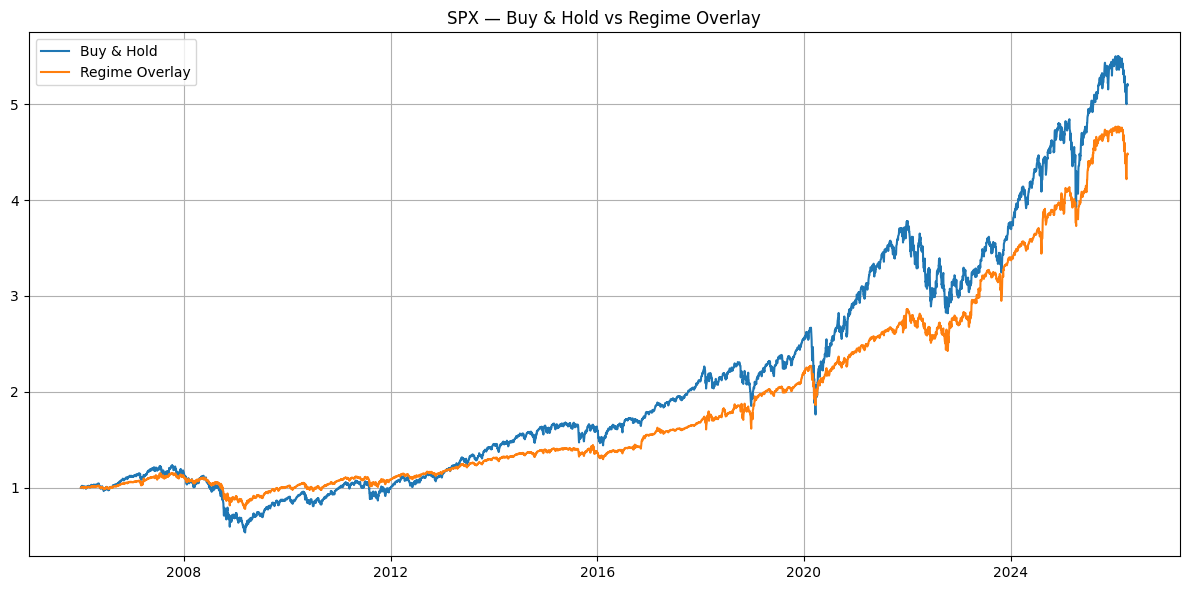

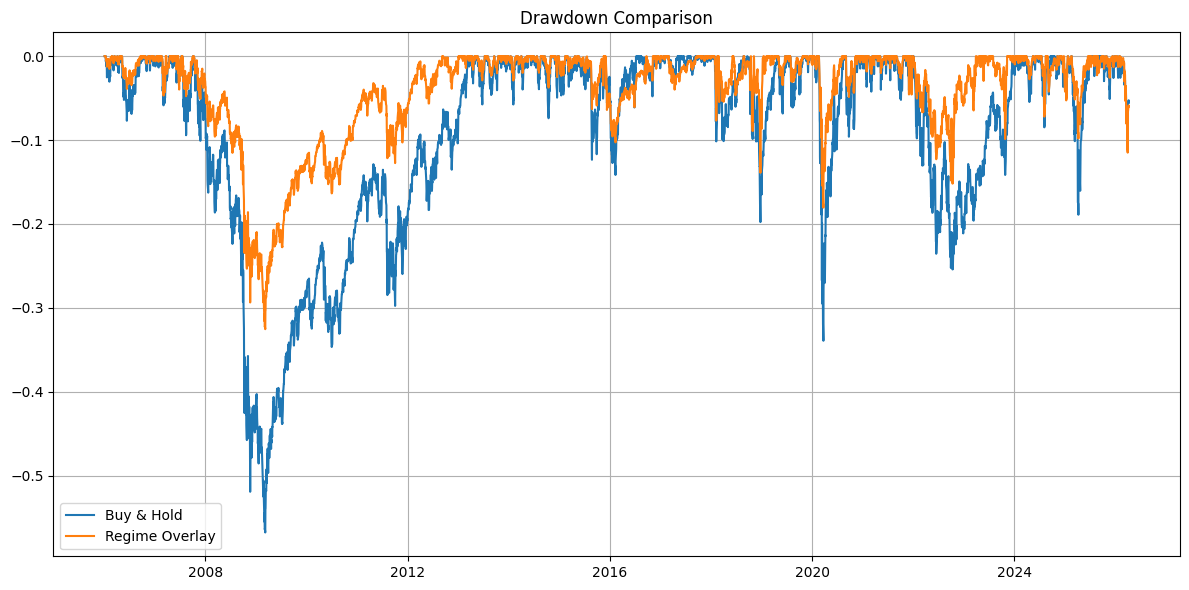

In [11]:
import matplotlib.pyplot as plt

# Equity
plt.figure(figsize=(12, 6))
plt.plot(df_overlay.index, df_overlay["equity_bh"], label="Buy & Hold")
plt.plot(df_overlay.index, df_overlay["equity_regime"], label="Regime Overlay")
plt.title("SPX — Buy & Hold vs Regime Overlay")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("equity_regime_overlay.png", dpi=200)
plt.show()

# Drawdown
dd_bh = df_overlay["equity_bh"] / df_overlay["equity_bh"].cummax() - 1
dd_reg = df_overlay["equity_regime"] / df_overlay["equity_regime"].cummax() - 1

plt.figure(figsize=(12, 6))
plt.plot(dd_bh, label="Buy & Hold")
plt.plot(dd_reg, label="Regime Overlay")
plt.title("Drawdown Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("drawdown_regime_overlay.png", dpi=200)
plt.show()